In [ ]:

import os
import ast
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = "jobs_clean_final_sbert_ready.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (8303, 7)

Columns: ['title_clean', 'title_clean_std', 'skills_clean', 'skills_text', 'combined_text', 'combined_text_clean', 'sbert_text']


,title_clean,title_clean_std,skills_clean,skills_text,combined_text,combined_text_clean,sbert_text
0,client acquisition,client acquisition,"['management', 'client', 'customer', 'event', ...",management ; client ; customer ; event ; ads ;...,management client customer event ads communica...,management client customer event ads communica...,client acquisition | management ; client ; cus...
1,human resources,human resources,"['excel', 'communication', 'office', 'ms', 'ef...",excel ; communication ; office ; ms ; effectiv...,excel communication office ms effective profic...,excel communication office ms effective profic...,human resources | excel ; communication ; offi...
2,human resources,human resources,"['coordination', 'excel', 'communication', 'of...",coordination ; excel ; communication ; office ...,coordination excel communication office screen...,coordination excel communication office screen...,human resources | coordination ; excel ; commu...
3,human resources,human resources,"['effective', 'excel', 'communication']",effective ; excel ; communication,effective excel communication selected interns...,effective excel communication assist with the ...,human resources | effective ; excel ; communic...
4,operations and travel coordination,operations and travel coordination,"['excel', 'communication', 'effective', 'opera...",excel ; communication ; effective ; operations...,excel communication effective operations profi...,excel communication effective operations profi...,operations and travel coordination | excel ; c...


In [ ]:
print("Missing values:\n", df.isna().sum().sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 title_clean            0
title_clean_std        0
skills_clean           0
skills_text            0
combined_text          0
combined_text_clean    0
sbert_text             0
dtype: int64

Duplicate rows: 0

Data types:
 title_clean            str
title_clean_std        str
skills_clean           str
skills_text            str
combined_text          str
combined_text_clean    str
sbert_text             str
dtype: object


In [ ]:
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

In [ ]:
def safe_parse_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

# Convert skills column
df["skills_list"] = df["skills_clean"].apply(safe_parse_list)

# Feature engineering
df["num_skills"] = df["skills_list"].apply(len)
df["combined_word_count"] = df["combined_text_clean"].astype(str).str.split().apply(len)
df["combined_char_count"] = df["combined_text_clean"].astype(str).str.len()
df["skills_text_char_count"] = df["skills_text"].astype(str).str.len()

df.head()

,title_clean,title_clean_std,skills_clean,skills_text,combined_text,combined_text_clean,sbert_text,skills_list,num_skills,combined_word_count,combined_char_count,skills_text_char_count
0,client acquisition,client acquisition,"['management', 'client', 'customer', 'event', ...",management ; client ; customer ; event ; ads ;...,management client customer event ads communica...,management client customer event ads communica...,client acquisition | management ; client ; cus...,"[management, client, customer, event, ads, com...",19,55,437,207
1,human resources,human resources,"['excel', 'communication', 'office', 'ms', 'ef...",excel ; communication ; office ; ms ; effectiv...,excel communication office ms effective profic...,excel communication office ms effective profic...,human resources | excel ; communication ; offi...,"[excel, communication, office, ms, effective, ...",6,32,252,61
2,human resources,human resources,"['coordination', 'excel', 'communication', 'of...",coordination ; excel ; communication ; office ...,coordination excel communication office screen...,coordination excel communication office screen...,human resources | coordination ; excel ; commu...,"[coordination, excel, communication, office, s...",11,26,206,117
3,human resources,human resources,"['effective', 'excel', 'communication']",effective ; excel ; communication,effective excel communication selected interns...,effective excel communication assist with the ...,human resources | effective ; excel ; communic...,"[effective, excel, communication]",3,65,489,33
4,operations and travel coordination,operations and travel coordination,"['excel', 'communication', 'effective', 'opera...",excel ; communication ; effective ; operations...,excel communication effective operations profi...,excel communication effective operations profi...,operations and travel coordination | excel ; c...,"[excel, communication, effective, operations, ...",5,101,769,60


C:\Users\mishr\AppData\Local\Temp\ipykernel_13652\1105559552.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")


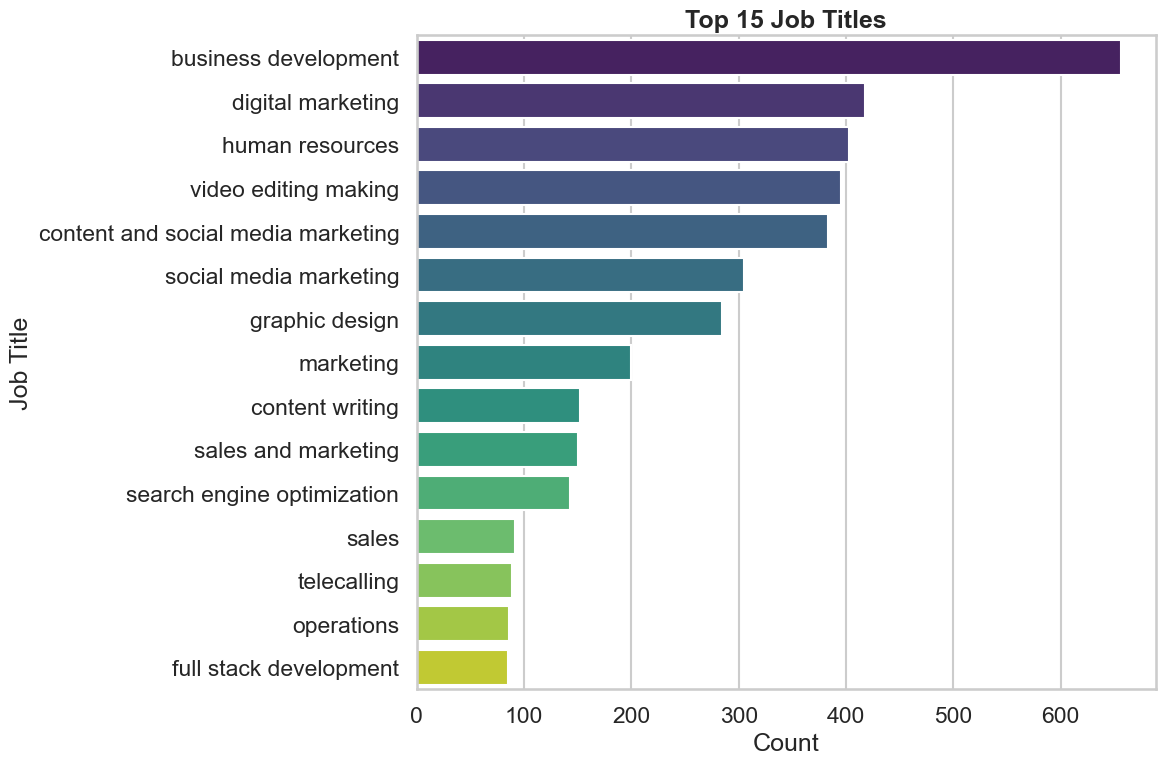

In [ ]:
title_col = "title_clean_std" if "title_clean_std" in df.columns else "title_clean"

top_titles = df[title_col].value_counts().head(15)

top_titles

# Visualization

plt.figure(figsize=(12, 8))
sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")

plt.title("Top 15 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

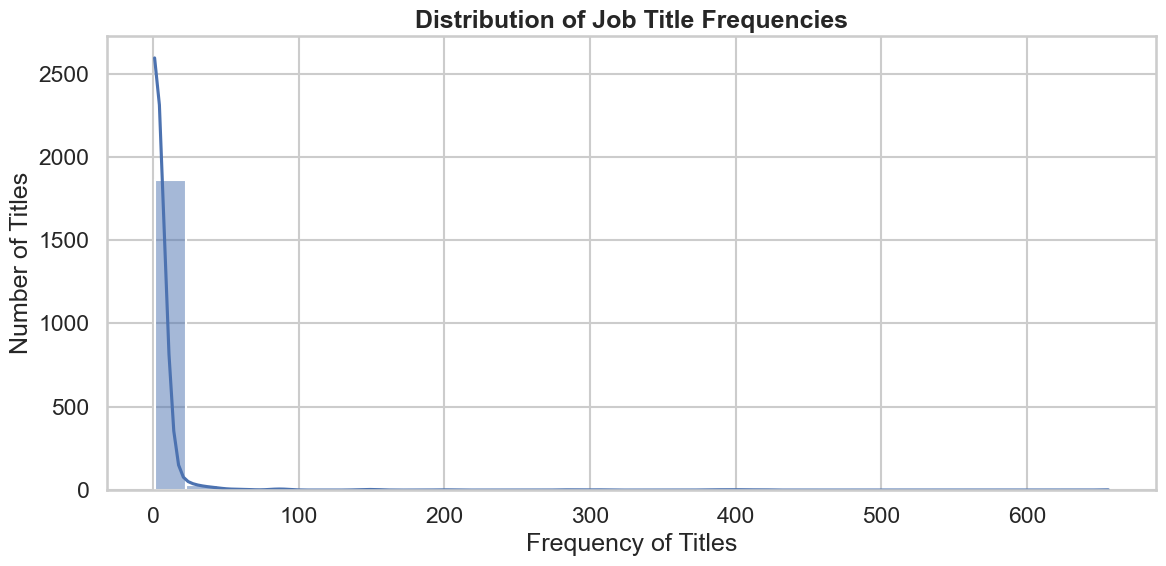

In [ ]:
title_counts = df[title_col].value_counts()

plt.figure(figsize=(12, 6))
sns.histplot(title_counts, bins=30, kde=True)

plt.title("Distribution of Job Title Frequencies")
plt.xlabel("Frequency of Titles")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

C:\Users\mishr\AppData\Local\Temp\ipykernel_13652\3146018084.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette="magma")


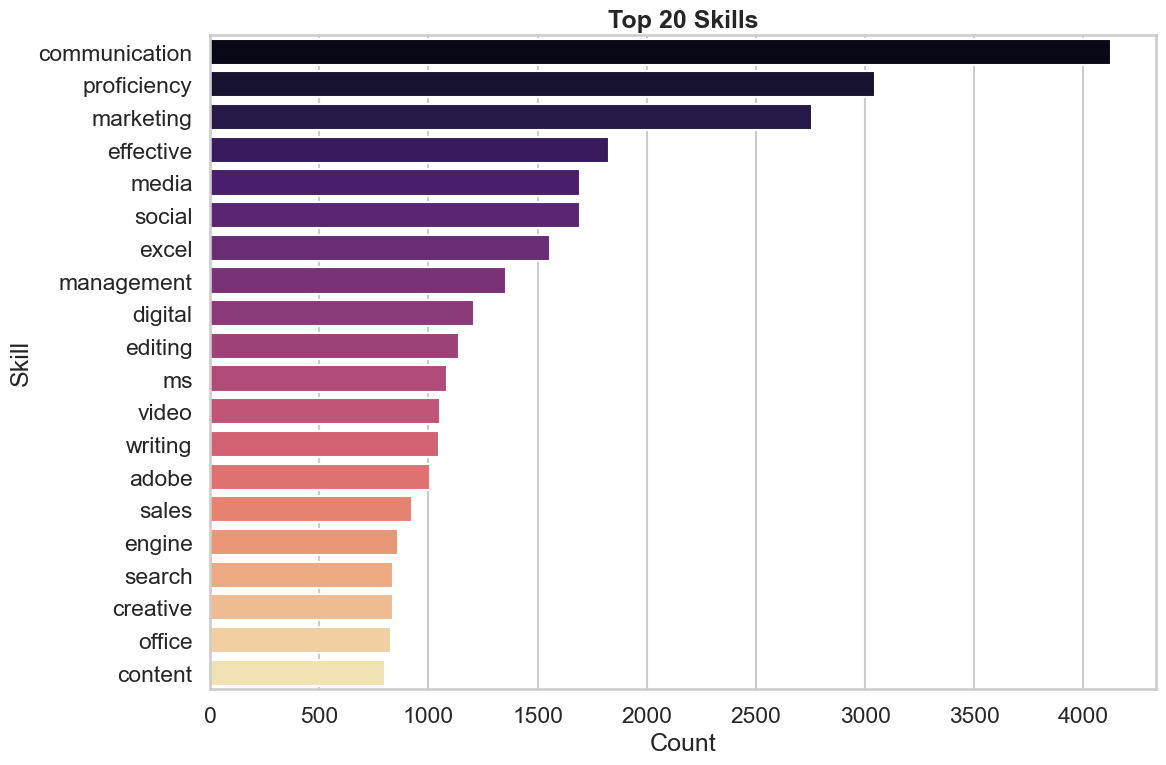

In [ ]:
all_skills = [
    skill.strip().lower()
    for skills in df["skills_list"]
    for skill in skills
    if str(skill).strip()
]

skill_counts = Counter(all_skills)
top_skills = pd.Series(skill_counts).sort_values(ascending=False).head(20)

top_skills

# Visualization

plt.figure(figsize=(12, 8))
sns.barplot(x=top_skills.values, y=top_skills.index, palette="magma")

plt.title("Top 20 Skills")
plt.xlabel("Count")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

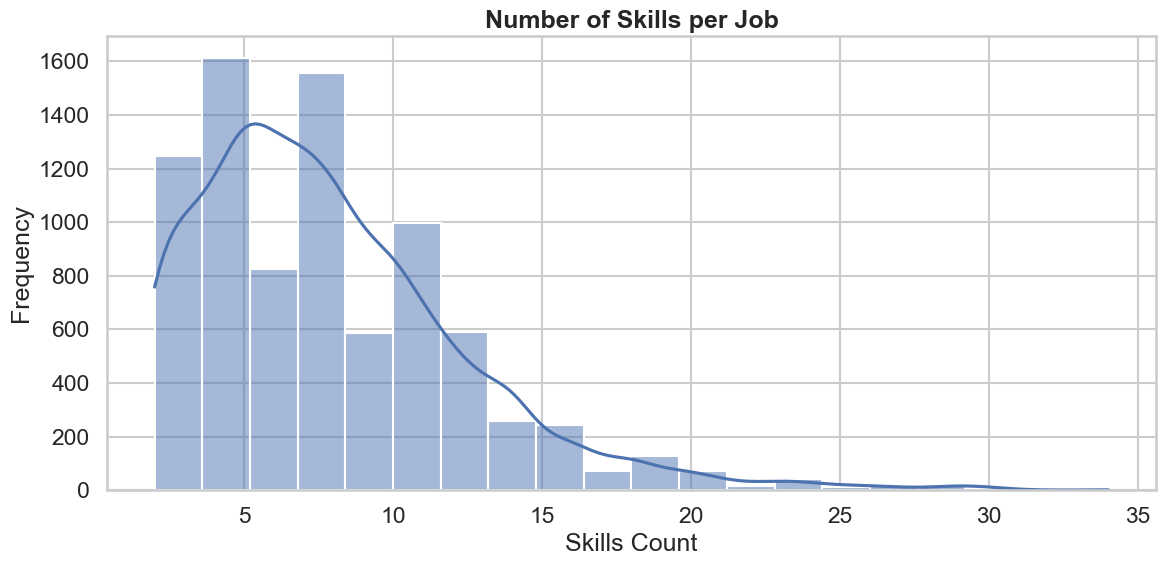

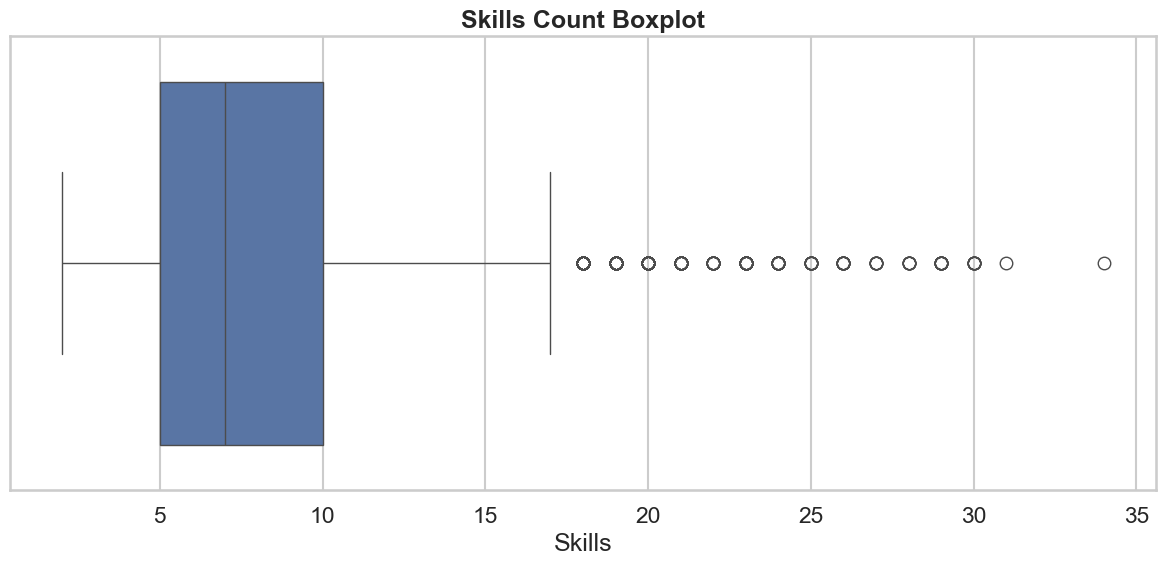

In [ ]:
plt.figure()
sns.histplot(df["num_skills"], bins=20, kde=True)

plt.title("Number of Skills per Job")
plt.xlabel("Skills Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Boxplot

plt.figure()
sns.boxplot(x=df["num_skills"])

plt.title("Skills Count Boxplot")
plt.xlabel("Skills")

plt.tight_layout()
plt.show()

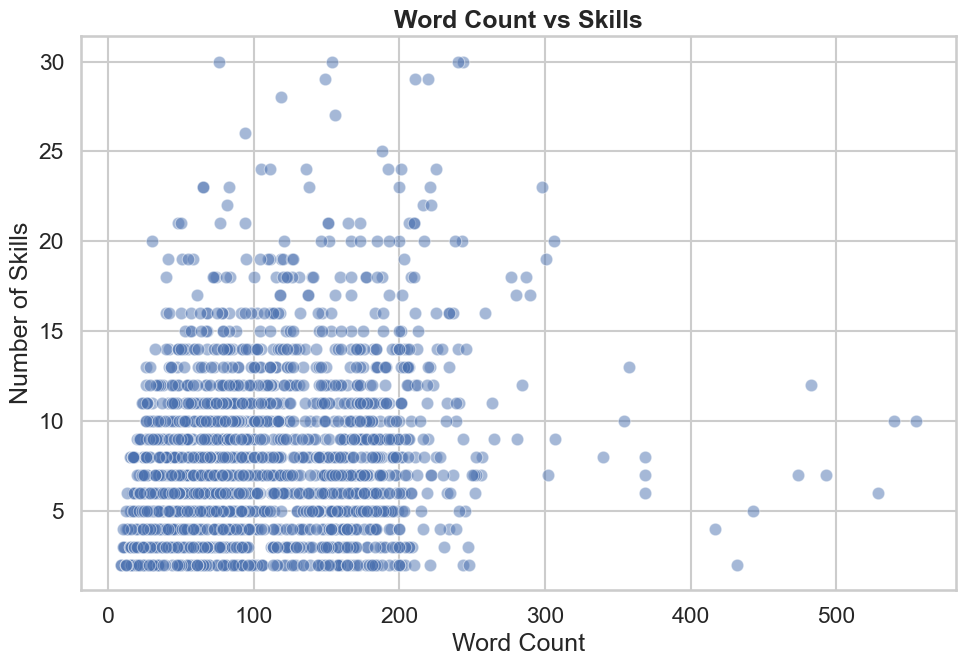

In [ ]:
sample_df = df.sample(min(len(df), 2000), random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=sample_df,
    x="combined_word_count",
    y="num_skills",
    alpha=0.5
)

plt.title("Word Count vs Skills")
plt.xlabel("Word Count")
plt.ylabel("Number of Skills")

plt.tight_layout()
plt.show()

In [ ]:
print("Total rows:", len(df))
print("Unique titles:", df[title_col].nunique())

print("\nSkills:")
print("Mean:", round(df["num_skills"].mean(), 2))
print("Median:", round(df["num_skills"].median(), 2))

print("\nDescription Length:")
print("Mean words:", round(df["combined_word_count"].mean(), 2))
print("Median words:", round(df["combined_word_count"].median(), 2))

Total rows: 8303
Unique titles: 1911

Skills:
Mean: 7.88
Median: 7.0

Description Length:
Mean words: 107.14
Median words: 91.0


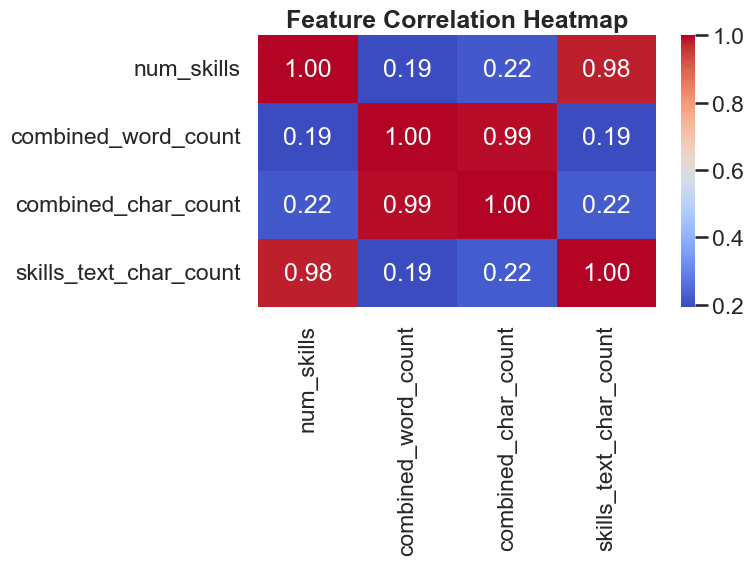

In [ ]:
numeric_df = df[[
    "num_skills",
    "combined_word_count",
    "combined_char_count",
    "skills_text_char_count"
]]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()